In [11]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 

In [12]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(42)

def generate_students(n=200, seed=42):
 	rng = np.random.default_rng(seed)
 	hours_studied = rng.normal(5, 2, n).clip(1, 10)
 	marks = (hours_studied * rng.uniform(8, 12, n) + rng.normal(0, 5, n)).clip(30, 100)
 	gender = rng.choice(['Male', 'Female'], n)
 	subject = rng.choice(['Math', 'Science', 'English', 'History'], n)
 	study_method = rng.choice(['Solo', 'Group'], n, p=[0.6, 0.4])
 	attempts = rng.integers(1, 4, n)
 	return pd.DataFrame({
     	'hours_studied': hours_studied.round(2),
     	'marks': marks.round(2),
     	'gender': gender,
     	'subject': subject,
     	'study_method': study_method,
     	'attempts': attempts
 	})

def generate_daily_sales(n=60, seed=42):
 	rng = np.random.default_rng(seed)
 	base = pd.date_range(start='2024-01-01', periods=n, freq='D')
 	trend = np.linspace(50, 80, n)
 	season = 8 * np.sin(np.linspace(0, 3*np.pi, n))
 	noise = rng.normal(0, 3, n)
 	sales = (trend + season + noise).round(2)
 	return pd.DataFrame({'date': base, 'sales': sales})

# Example usage
# students = generate_students(220)
# sales = generate_daily_sales(90)

Problems
Using sales, draw a lineplot of date vs sales.
From students, plot hours_studied vs marks and color by gender.
Create a grid of scatterplots (hours_studied vs marks) faceted by subject.
Plot a histogram of marks with a KDE overlay.
Show the KDE curve for hours_studied.
Display the count of records per subject.
Draw a regression line for hours_studied and marks.
Create a pairplot and a jointplot for students' dataset.
Make a scatter plot of hours_studied vs marks using Plotly, colored by gender.
Draw a line chart of sales over date and a histogram of marks using Plotly.


In [18]:
students = generate_students(200)
sales = generate_daily_sales(60)

In [21]:
students.head()

,hours_studied,marks,gender,subject,study_method,attempts
0,5.61,33.64,Male,English,Solo,2
1,2.92,30.00,Female,History,Solo,3
2,6.50,53.08,Male,Science,Group,2
3,6.88,76.00,Male,History,Group,2
4,1.10,30.00,Female,Science,Solo,2


In [19]:
sales.head()

,date,sales
0,2024-01-01,50.91
1,2024-01-02,48.66
2,2024-01-03,55.78
3,2024-01-04,58.04
4,2024-01-05,50.95


<Axes: xlabel='date', ylabel='sales'>

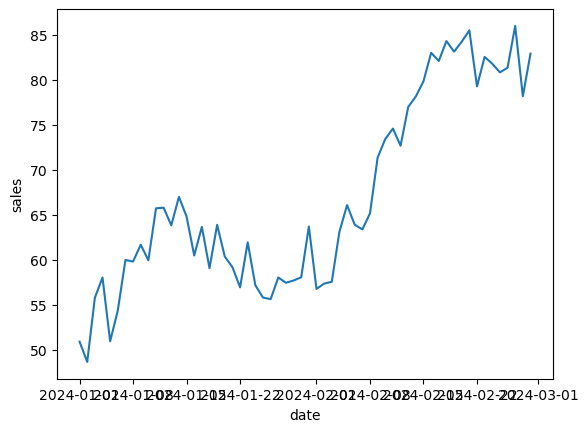

In [23]:
# Using sales, draw a lineplot of date vs sales.
sns.lineplot(data=sales,x='date',y='sales')

<Axes: xlabel='hours_studied', ylabel='marks'>

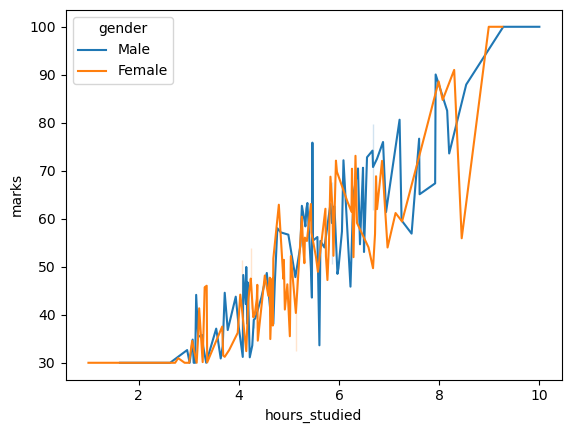

In [26]:
# From students, plot hours_studied vs marks and color by gender
sns.lineplot(data=students, x='hours_studied',y='marks',hue='gender')

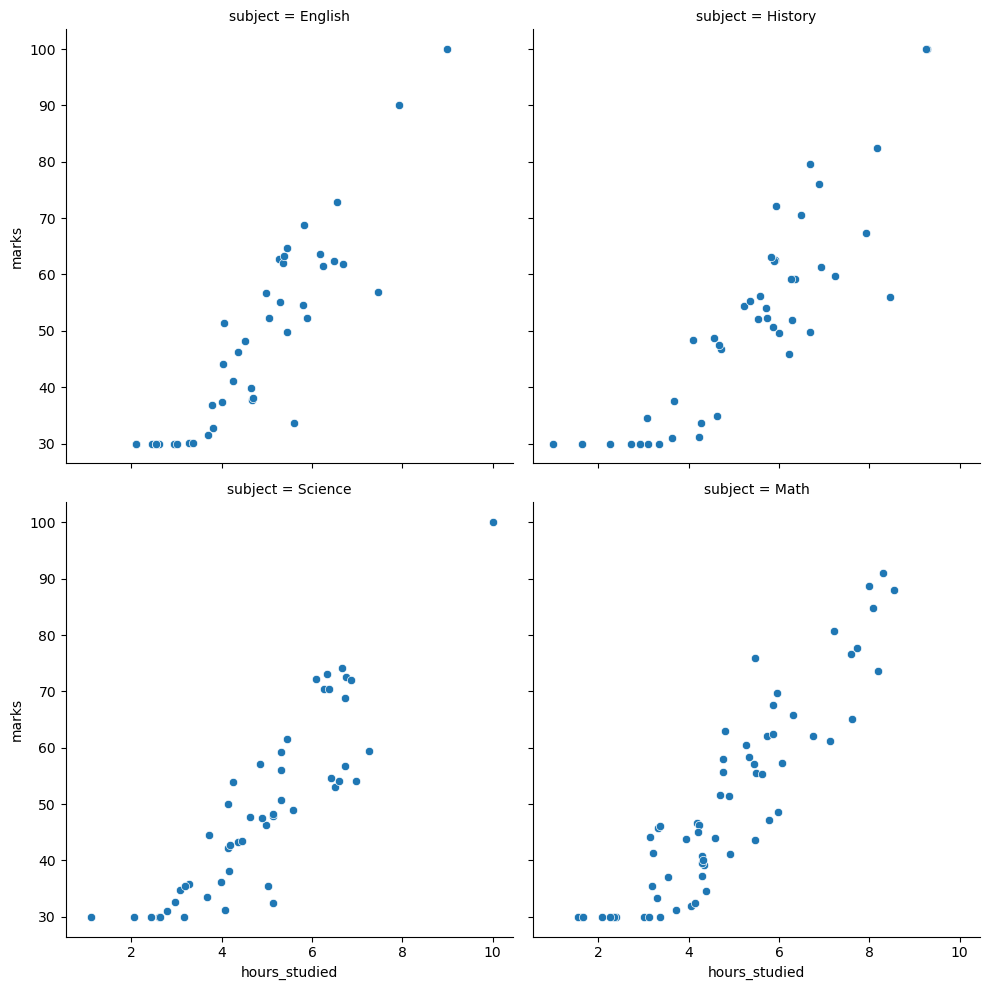

In [31]:
# Create a grid of scatterplots (hours_studied vs marks) faceted by subject.
sns.relplot(kind='scatter',data=students, x='hours_studied',y='marks',col='subject',col_wrap=2)

<Axes: xlabel='marks', ylabel='Count'>

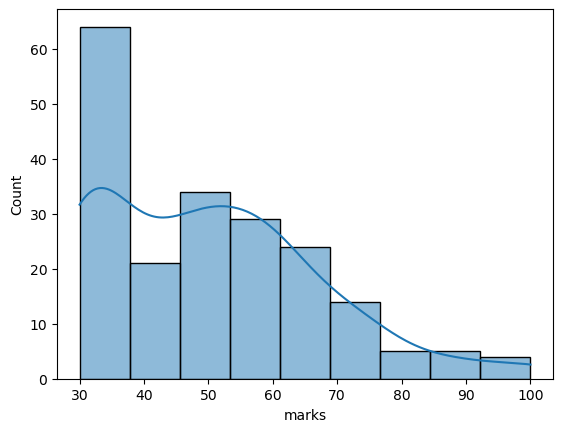

In [37]:
# Plot a histogram of marks with a KDE overlay.
sns.histplot(data=students,x='marks',kde=True)

<Axes: xlabel='hours_studied', ylabel='Density'>

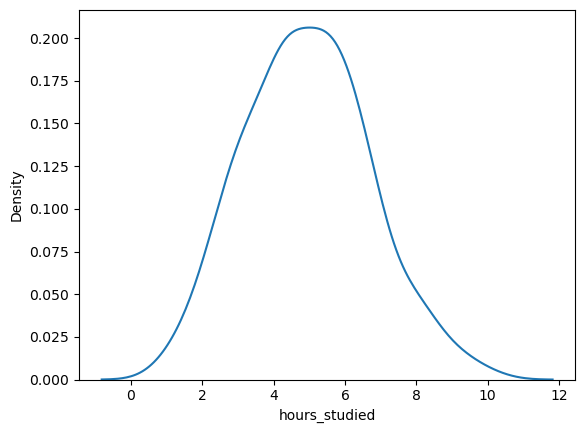

In [38]:
# Show the KDE curve for hours_studied.
sns.kdeplot(data=students,x='hours_studied')

<Axes: xlabel='subject', ylabel='count'>

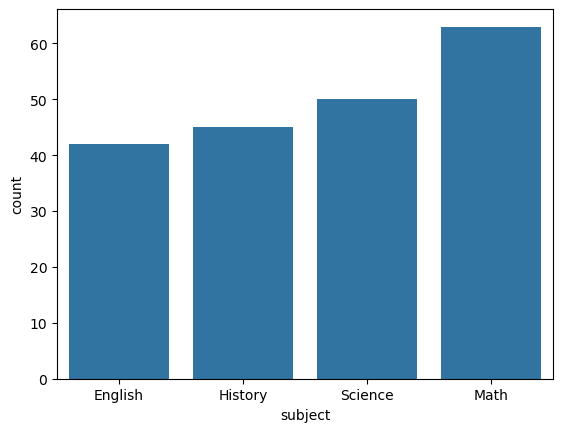

In [39]:
# Display the count of records per subject.
sns.countplot(data=students, x='subject')

<Axes: xlabel='hours_studied', ylabel='marks'>

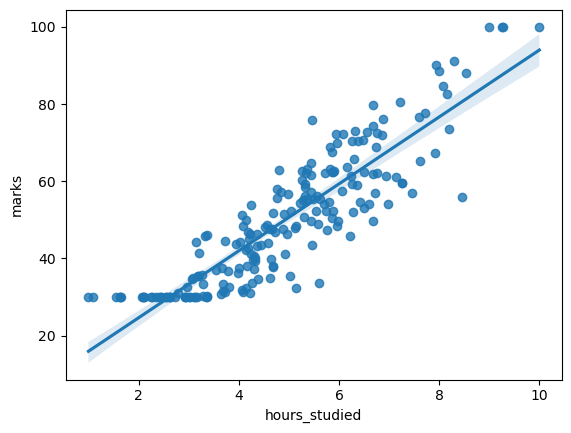

In [41]:
# Draw a regression line for hours_studied and marks.
sns.regplot(data=students, x='hours_studied', y='marks')

In [45]:
# Create a pairplot and a jointplot for students' dataset
students.head()
all_data=students[['hours_studied','marks','gender','subject','study_method','attempts']]

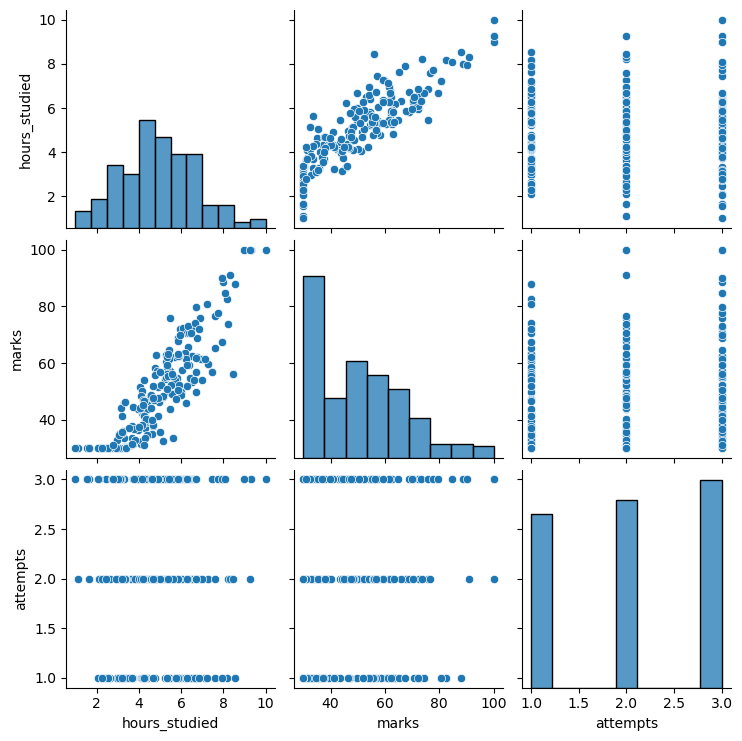

In [46]:
sns.pairplot(data=all_data)

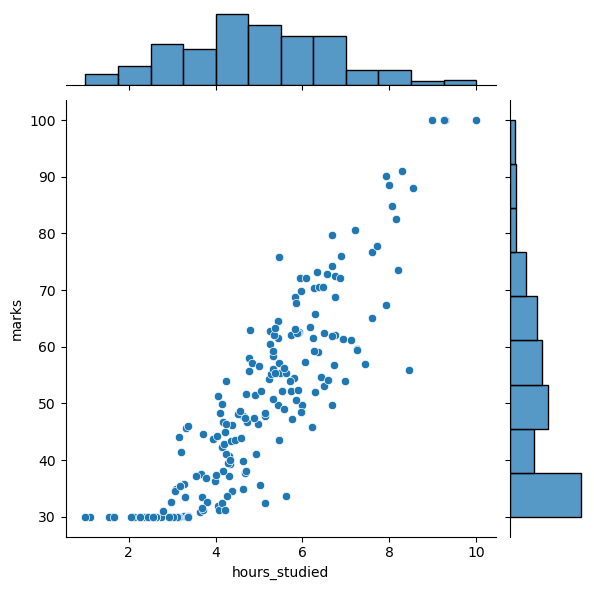

In [48]:
sns.jointplot(data=all_data,x='hours_studied',y='marks')

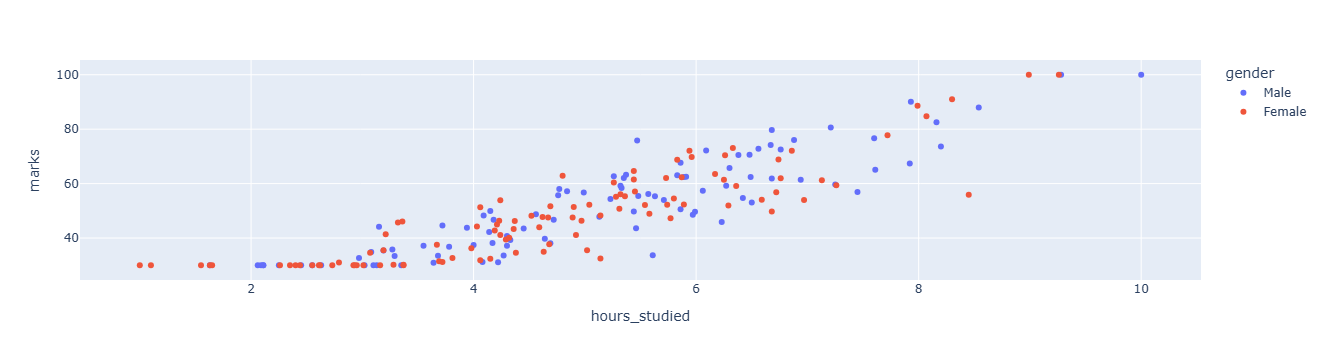

In [51]:
# Make a scatter plot of hours_studied vs marks using Plotly, colored by gender.
fig=px.scatter(students,x='hours_studied',y='marks', color='gender')
fig.show()

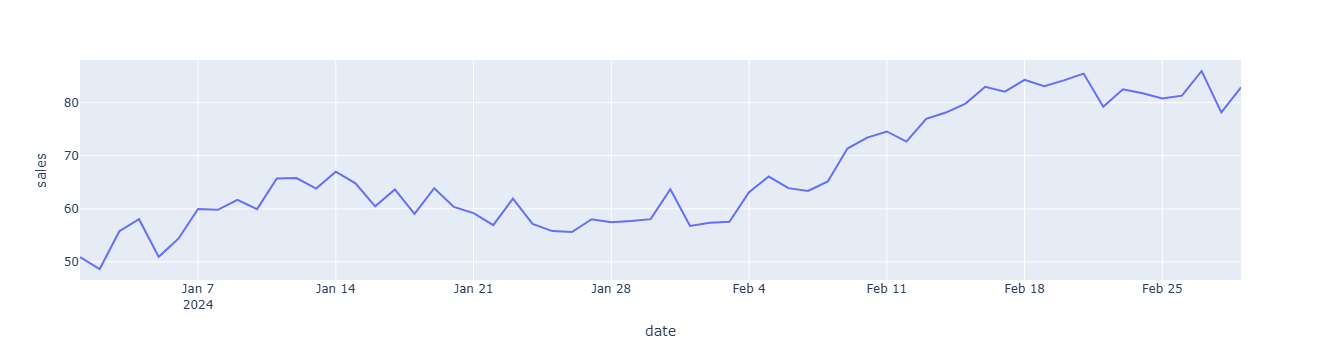

In [52]:
# Draw a line chart of sales over date and a histogram of marks using Plotly
fig1 = px.line(sales, x='date', y='sales')
fig1.show()

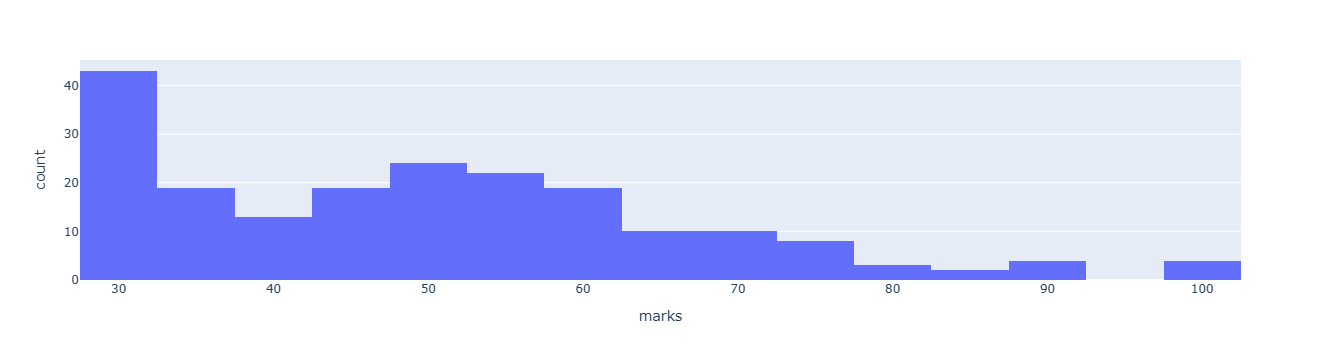

In [53]:
fig2 = px.histogram(students, x='marks')
fig2.show()